# A 3D Geological Model of the Molasse Unit in the Hochgrat Region, Allgäu, Germany
### Based on Field-Observed Structural Orientation Data from Alpine Outcrops

**Author :** Ariful Bari Khandaker

**Supervisors:** Nils Chudala, David Nathan, and Florian Wellmann


![map example](3d_model.png)

In a fieldtrip, We gathered orientation data of structural features and bedding of molasse sediments. Remote sensing data from BayernAtlas.de was utilized in the form of a Digital Terrain Model (DTM) with a 1mx1m resolution. Raster files and shapefiles are displayed in a leafmap map. To run this notebook, we suggest starting with a new python environment, as leafmap can be tricky to install, according to its developers. For the development of this notebook, Mamba was used and the following installation steps were conducted:

```
mamba create -n geo leafmap geopandas localtileserver python==3.12 -c conda-forge
mamba activate geo
mamba install jupyter
pip install gempy[opt]
mamba install xarray
pip install mplstereonet
```

<br>Note: At the current time, skimage (used by gempy) cannot be installed in python 3.13 in windows, using pip.</br>

## Steps covered:
- Loading in geo data into map
- Processing orientation data
- Sampling elevation data from raster
- Computing and visualizing simple geo model
- Creating georeferenced geo map
- Plot the stereonet from the measured orientation dataset
- calculate the opening angle of the fold limbs
- **Special Note**

# Import packages

In [2]:
import os
import leafmap.leafmap as leafmap
import geopandas as gpd
import matplotlib.pyplot as plt
import mplstereonet
import gempy as gp
import gempy_viewer as gpv
import pandas as pd
import rasterio
import numpy as np
from gempy.modules.data_manipulation.manipulate_points import convert_orientation_to_pole_vector

Setting Backend To: AvailableBackends.numpy


# Load in geo data into map

In [3]:
m = leafmap.Map(layers_control=True)

In [4]:
m.add_raster("Hochgrat_dtm_1x1.tif", colormap="terrain", layer_name="DTM")


In [5]:
m.add_raster("Hochgrat_slope_1x1.tif", colormap="inferno", layer_name="Slope")

In [6]:
os.listdir("shp")

['Extra',
 'molasse_interface_lines.gpkg',
 'molasse_interface_lines_add1_updated.gpkg',
 'molasse_orientation_2025.gpkg']

In [7]:
#m.add_shp("shp/molasse_interface_lines.shp", layer_name="Interface")
m.add_shp("shp/molasse_interface_lines.gpkg", layer_name="Interface")

In [8]:
#m.add_geojson("shp/molasse_orientation_2025.geojson", layer_name="Orientations", popup=["id", "formation"])
m.add_geojson("shp/molasse_orientation_2025.gpkg", layer_name="Orientations", popup=["id", "formation"])


In [9]:
m


Map(center=[47.4879415, 10.0893905], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title…

In [9]:
#orientation data
ori_gdf = gpd.read_file("shp/molasse_orientation_2025.gpkg")
ori_gdf

,X,Y,Dip_Direc,Dip_angle,geometry
0,47.490556,10.110556,161,53,POINT (583654.299 5260277.794)
1,47.490833,10.102500,145,43,POINT (583047.07 5260300.024)
2,47.491389,10.102500,154,55,POINT (583046.194 5260361.765)
3,47.492500,10.101389,329,48,POINT (582960.75 5260484.061)
4,47.493070,10.099760,323,33,POINT (582837.161 5260545.67)
5,47.495278,10.093333,151,30,POINT (582349.638 5260784.199)
6,47.495278,10.092778,150,63,POINT (582307.795 5260783.611)
7,47.494444,10.087778,159,53,POINT (581932.496 5260685.714)
8,47.493056,10.088889,166,54,POINT (582018.348 5260532.534)
9,47.491111,10.087500,332,54,POINT (581916.758 5260314.974)


# Preprocessing orientation data

> **_NOTE_**: The same coordinate system (UTM 32N (Projected CRS: EPSG:25832)in this case) is used in all modelling steps.

In [10]:
dtm = rasterio.open("Hochgrat_dtm_1x1.tif")
print(dtm.crs)
#dtm.close()

EPSG:25832


In [11]:
ori_gdf.crs

<Projected CRS: EPSG:25832>
Name: ETRS89 / UTM zone 32N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Europe between 6°E and 12°E: Austria; Denmark - onshore and offshore; Germany - onshore and offshore; Italy - onshore and offshore; Norway including Svalbard - onshore and offshore; Spain - offshore.
- bounds: (6.0, 36.53, 12.01, 84.01)
Coordinate Operation:
- name: UTM zone 32N
- method: Transverse Mercator
Datum: European Terrestrial Reference System 1989 ensemble
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [12]:
ori_gdf = ori_gdf.to_crs("25832")
ori_gdf[["x", "y"]] = ori_gdf.geometry.get_coordinates()

# Use rasterio to sample elevation from DTM

In [13]:
# Extract X and Y from geometry
ori_df = pd.DataFrame({
    "X": ori_gdf.geometry.x,
    "Y": ori_gdf.geometry.y,
})

In [14]:
coords = ori_df[["X", "Y"]].values

dtm = rasterio.open("Hochgrat_dtm_1x1.tif")
elevations = [z[0] for z in dtm.sample(coords)]
dtm.close()

ori_df["Z"] = elevations



In [15]:
#add dip and azimuth in ori_df

ori_df['dip']= ori_gdf['Dip_angle']
ori_df['azimuth']= ori_gdf['Dip_Direc']

#add foramtion name and polarity for gempy
ori_df["formation"] = [f'formation{i:02d}' for i in range(1,len(ori_df)+1)]
ori_df["polarity"] = 1
ori_df

,X,Y,Z,dip,azimuth,formation,polarity
0,583654.299015,5.260278e+06,1287.043091,53,161,formation01,1
1,583047.070111,5.260300e+06,1342.298096,43,145,formation02,1
2,583046.194205,5.260362e+06,1350.264038,55,154,formation03,1
3,582960.750288,5.260484e+06,1374.388062,48,329,formation04,1
4,582837.161000,5.260546e+06,1385.579102,33,323,formation05,1
5,582349.638290,5.260784e+06,1517.892090,30,151,formation06,1
6,582307.794815,5.260784e+06,1515.967041,63,150,formation07,1
7,581932.496132,5.260686e+06,1570.537109,53,159,formation08,1
8,582018.347958,5.260533e+06,1585.563110,54,166,formation09,1
9,581916.757696,5.260315e+06,1568.286133,54,332,formation10,1


# Display orientation data and mapped interfaces to surfaces for geomodel 

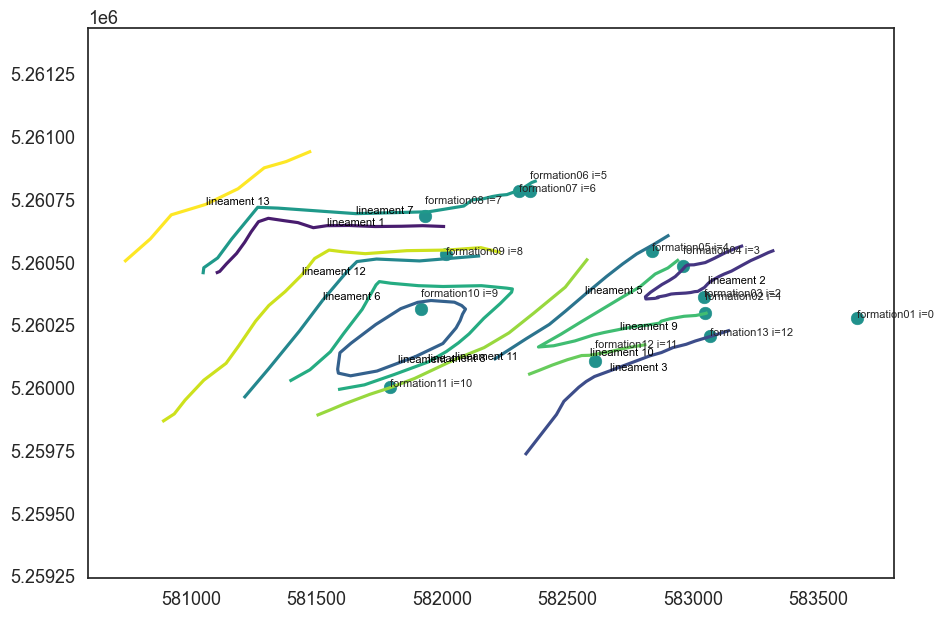

In [16]:
import geopandas as gpd
import matplotlib.pyplot as plt

surf_gdf = gpd.read_file("shp/molasse_interface_lines_add1_updated.gpkg")

fig, ax = plt.subplots()

cmap = plt.colormaps.get_cmap("viridis")
ori_gdf.plot(ax=ax, color=cmap(0.5), label="Orientations")

# Plot surf_gdf lines
for i in surf_gdf.index:
    surf_gdf.loc[[i]].plot(
        ax=ax,
        label=surf_gdf.loc[i, "formation"] + f" i={i}",
        color=cmap((i+1)/len(surf_gdf))
    )

    # Get a representative point along the line to place the label
    rep_point = surf_gdf.loc[i, "geometry"].representative_point()
    ax.text(
        rep_point.x, rep_point.y,
        s=surf_gdf.loc[i, "formation"],  
        fontsize=8,
        color="black"
    )

# Plot orientation labels
for i in ori_df.index:
    plt.text(
        x=ori_df.loc[i, "X"],
        y=ori_df.loc[i,"Y"]+(i%2)*50,
        s=ori_df.loc[i, "formation"]+ f" i={i}",
        fontsize=8
    )

#plt.legend()
plt.axis("equal")
plt.show()


In [ ]:
#get the model area extent from surf_gdf

xmin = surf_gdf.get_coordinates()["x"].min(axis=0)
ymin = surf_gdf.get_coordinates()["y"].min(axis=0)
xmax = surf_gdf.get_coordinates()["x"].max(axis=0)
ymax = surf_gdf.get_coordinates()["y"].max(axis=0)


In [18]:
geo_model: gp.data.GeoModel = gp.create_geomodel(
    project_name='Hochgrat Mapping',
    extent=[xmin, xmax, ymin, ymax, 1400, 1900],
    resolution=[120, 120, 80],
    refinement=3,
    structural_frame=gp.data.StructuralFrame.initialize_default_structure()
)


In [19]:
geo_model.structural_frame

StructuralFrame(
	structural_groups=[
StructuralGroup(
	name=default_formations,
	structural_relation=StackRelationType.ERODE,
	elements=[
Element(
	name=surface1,
	color=#015482,
	is_active=True
)
]
)
],
	fault_relations=
[[False]],

In [20]:
# add first layer
# we assign lineament 4 and 8 to parts of one surface. This should be the youngest surface.
# furthermore, orientation measurement 10 and 11 (idx 9, 10) belong to this layer as well


# add surface points
lineament_selection = surf_gdf.loc[[3,7]]
# extract x and y coordinates
x_sp = lineament_selection.get_coordinates().values[:,0]
y_sp = lineament_selection.get_coordinates().values[:,1]

# sample elevation from DTM
dtm = rasterio.open("Hochgrat_dtm_1x1.tif")
z_sp = np.array([z[0] for z in dtm.sample(lineament_selection.get_coordinates().values)])
dtm.close()

gp.add_surface_points(
    geo_model=geo_model,
    x=x_sp,
    y=y_sp,
    z=z_sp,
    elements_names=['surface1']*len(x_sp)
    )

# add orientations
ori_selections = ori_df.loc[[9,10]]
x_or = ori_selections["X"].values
y_or = ori_selections["Y"].values
z_or = ori_selections["Z"].values
orientation = ori_selections[["azimuth", "dip", "polarity"]].values

for i in range(len(x_or)):
    gradient = convert_orientation_to_pole_vector([orientation[i,0]], [orientation[i,1]], [orientation[i,2]])
    gp.add_orientations(
        geo_model=geo_model,
        x=[x_or[i]],
        y=[y_or[i]],
        z=[z_or[i]],
        pole_vector=gradient,
        elements_names="surface1"
    )
    

In [21]:
geo_model.update_transform(gp.data.GlobalAnisotropy.NONE)
gp.compute_model(geo_model, engine_config=gp.data.GemPyEngineConfig())

Setting Backend To: AvailableBackends.numpy
Chunking done: 120 chunks


Solutions(3 Octree Levels, 1 DualContouringMeshes)

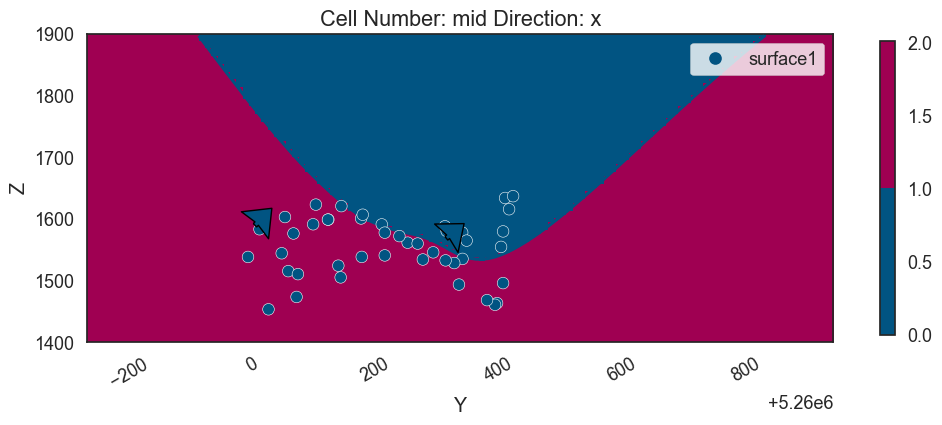

In [ ]:
gpv.plot_2d(geo_model, direction="x")

In [ ]:
#plot the 3D model

gpv.plot_3d(geo_model)

In [24]:
# add second layer
# we assign lineament 6,11,12,1,7,13 to the second youngest surface. 
# furthermore, orientation measurement 6,7,8,9 and 11 (idx 5,6,7,8,10) belong to this layer as well


# add surface points
lineament_selection = surf_gdf.loc[[0,5,6,10,11,12]]

# extract x and y coordinates
x_sp = lineament_selection.get_coordinates().values[:,0]
y_sp = lineament_selection.get_coordinates().values[:,1]

# sample elevation from DTM
dtm = rasterio.open("Hochgrat_dtm_1x1.tif")
z_sp = np.array([z[0] for z in dtm.sample(lineament_selection.get_coordinates().values)])
dtm.close()

element2 = gp.data.StructuralElement(
    name='surface2',
    color=next(geo_model.structural_frame.color_generator),
    surface_points=gp.data.SurfacePointsTable.initialize_empty(),
    orientations=gp.data.OrientationsTable.initialize_empty()
)

geo_model.structural_frame.structural_groups[0].append_element(element2)

gp.add_surface_points(
    geo_model=geo_model,
    x=x_sp,
    y=y_sp,
    z=z_sp,
    elements_names=['surface2']*len(x_sp)
    )

# add orientations
ori_selections = ori_df.loc[[5,6,7,8,10]]
x_or = ori_selections["X"].values
y_or = ori_selections["Y"].values
z_or = ori_selections["Z"].values
orientation = ori_selections[["azimuth", "dip", "polarity"]].values

for i in range(len(x_or)):
    gradient = convert_orientation_to_pole_vector([orientation[i,0]], [orientation[i,1]], [orientation[i,2]])
    gp.add_orientations(
        geo_model=geo_model,
        x=[x_or[i]],
        y=[y_or[i]],
        z=[z_or[i]],
        pole_vector=gradient,
        elements_names="surface2"
    )
    

In [25]:
# add third layer
# we assign lineament 3,5,10 to the middle surface. 
# furthermore, orientation measurement 1,5,12,13 (idx 0,4,11,12) belongs to this layer as well


# add surface points
lineament_selection = surf_gdf.loc[[2,4,9]]

# extract x and y coordinates
x_sp = lineament_selection.get_coordinates().values[:,0]
y_sp = lineament_selection.get_coordinates().values[:,1]

# sample elevation from DTM
dtm = rasterio.open("Hochgrat_dtm_1x1.tif")
z_sp = np.array([z[0] for z in dtm.sample(lineament_selection.get_coordinates().values)])
dtm.close()

element3 = gp.data.StructuralElement(
    name='surface3',
    color=next(geo_model.structural_frame.color_generator),
    surface_points=gp.data.SurfacePointsTable.initialize_empty(),
    orientations=gp.data.OrientationsTable.initialize_empty()
)

geo_model.structural_frame.structural_groups[0].append_element(element3)

gp.add_surface_points(
    geo_model=geo_model,
    x=x_sp,
    y=y_sp,
    z=z_sp,
    elements_names=['surface3']*len(x_sp)
    )

# add orientations
ori_selections = ori_df.loc[[0,4,11,12]]
x_or = ori_selections["X"].values
y_or = ori_selections["Y"].values
z_or = ori_selections["Z"].values
orientation = ori_selections[["azimuth", "dip", "polarity"]].values

for i in range(len(x_or)):
    gradient = convert_orientation_to_pole_vector([orientation[i,0]], [orientation[i,1]], [orientation[i,2]])
    gp.add_orientations(
        geo_model=geo_model,
        x=[x_or[i]],
        y=[y_or[i]],
        z=[z_or[i]],
        pole_vector=gradient,
        elements_names="surface3"
    )
    

In [26]:
# add 4th layer
# we assign lineament 2,9 to the oldest surface. 
# furthermore, orientation measurement 2,3,4 (idx 1,2,3) belongs to this layer as well


# add surface points
lineament_selection = surf_gdf.loc[[1,8]]

# extract x and y coordinates
x_sp = lineament_selection.get_coordinates().values[:,0]
y_sp = lineament_selection.get_coordinates().values[:,1]

# sample elevation from DTM
dtm = rasterio.open("Hochgrat_dtm_1x1.tif")
z_sp = np.array([z[0] for z in dtm.sample(lineament_selection.get_coordinates().values)])
dtm.close()

element4 = gp.data.StructuralElement(
    name='surface4',
    color=next(geo_model.structural_frame.color_generator),
    surface_points=gp.data.SurfacePointsTable.initialize_empty(),
    orientations=gp.data.OrientationsTable.initialize_empty()
)

geo_model.structural_frame.structural_groups[0].append_element(element4)

gp.add_surface_points(
    geo_model=geo_model,
    x=x_sp,
    y=y_sp,
    z=z_sp,
    elements_names=['surface4']*len(x_sp)
    )

# add orientations
ori_selections = ori_df.loc[[1,2,3]]
x_or = ori_selections["X"].values
y_or = ori_selections["Y"].values
z_or = ori_selections["Z"].values
orientation = ori_selections[["azimuth", "dip", "polarity"]].values

for i in range(len(x_or)):
    gradient = convert_orientation_to_pole_vector([orientation[i,0]], [orientation[i,1]], [orientation[i,2]])
    gp.add_orientations(
        geo_model=geo_model,
        x=[x_or[i]],
        y=[y_or[i]],
        z=[z_or[i]],
        pole_vector=gradient,
        elements_names="surface4"
    )
    

In [ ]:
#stack the surfaces

gp.map_stack_to_surfaces(geo_model,
                         {"default_formations":["surface4", "surface3", "surface2", "surface1"]}
                        )

StructuralFrame(
	structural_groups=[
StructuralGroup(
	name=default_formations,
	structural_relation=StackRelationType.ERODE,
	elements=[
Element(
	name=surface4,
	color=#443988,
	is_active=True
),
Element(
	name=surface3,
	color=#728f02,
	is_active=True
),
Element(
	name=surface2,
	color=#ffbe00,
	is_active=True
),
Element(
	name=surface1,
	color=#015482,
	is_active=True
)
]
)
],
	fault_relations=
[[False]],

In [28]:
geo_model.structural_frame

StructuralFrame(
	structural_groups=[
StructuralGroup(
	name=default_formations,
	structural_relation=StackRelationType.ERODE,
	elements=[
Element(
	name=surface4,
	color=#443988,
	is_active=True
),
Element(
	name=surface3,
	color=#728f02,
	is_active=True
),
Element(
	name=surface2,
	color=#ffbe00,
	is_active=True
),
Element(
	name=surface1,
	color=#015482,
	is_active=True
)
]
)
],
	fault_relations=
[[False]],

In [ ]:
#compute the model

geo_model.update_transform(gp.data.GlobalAnisotropy.NONE)
gp.compute_model(geo_model, engine_config=gp.data.GemPyEngineConfig())

Setting Backend To: AvailableBackends.numpy
Chunking done: 602 chunks


Solutions(3 Octree Levels, 4 DualContouringMeshes)

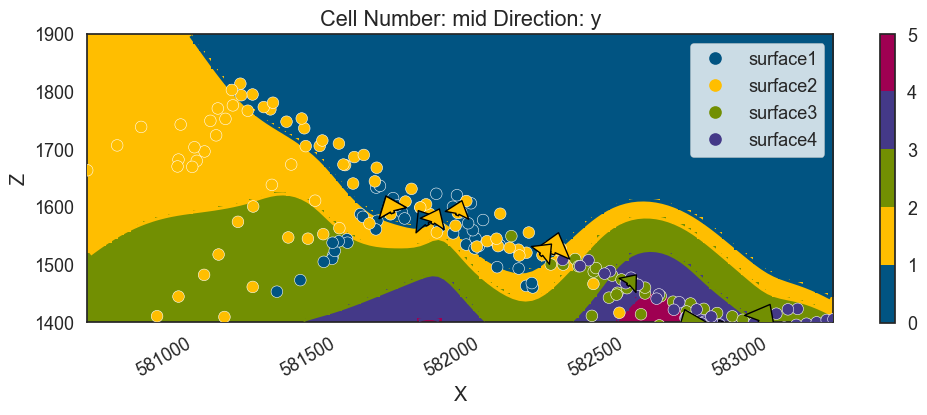

In [ ]:
#visualize the model in 2D

gpv.plot_2d(geo_model, direction="y", ve=2)

In [ ]:
#3d visualization

gpv.plot_3d(geo_model, ve=1)

# Create georeferenced geo map for GIS application
To complete the workflow, we finalize the modelling by creating a geological map for the model area. 

In [32]:
XX, YY = np.meshgrid(np.linspace(xmin, xmax, 200), np.linspace(ymin, ymax, 200))
map_coords = np.hstack([XX.reshape(-1,1), YY.reshape(-1,1)])

# sample elevation from DTM
dtm = rasterio.open("Hochgrat_dtm_1x1.tif")
z_map = np.array([z[0] for z in dtm.sample(map_coords)])


map_xyz = np.hstack([map_coords, z_map.reshape(-1,1)])

In [33]:
geo_sol : np.ndarray = gp.compute_model_at(
    gempy_model=geo_model,
    at=map_xyz
)
geo_sol

Active grids: GridTypes.CUSTOM|NONE
Setting Backend To: AvailableBackends.numpy
Chunking done: 22 chunks


array([2., 2., 3., ..., 5., 5., 5.])

This can already be displayed in matplotlib, for example like this:

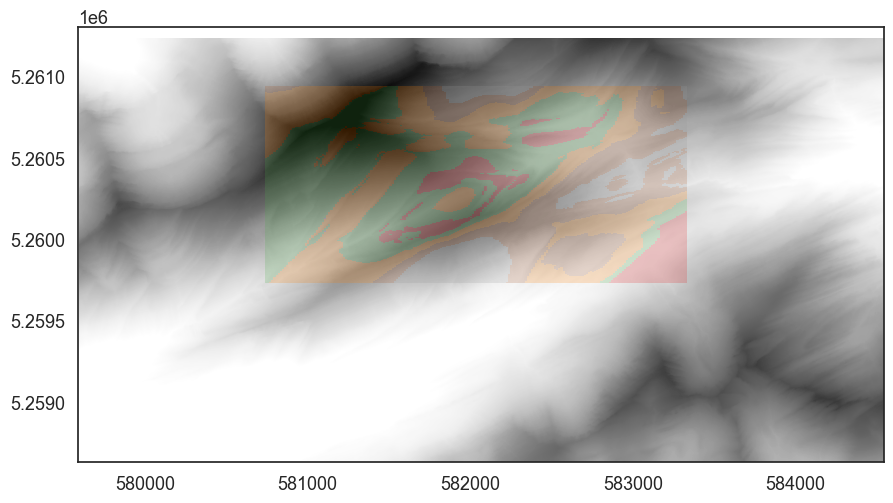

In [34]:
geo_map = np.flipud(geo_sol.reshape(XX.shape))
plt.imshow(dtm.read(1), extent=[dtm.bounds[0], dtm.bounds[2], dtm.bounds[1], dtm.bounds[3]], vmin=1200, vmax=1800)
plt.imshow(geo_map, extent=[xmin, xmax, ymin, ymax], cmap="Set1", interpolation="none", alpha=0.2)
plt.xlim(dtm.bounds[0], dtm.bounds[2])
plt.ylim(dtm.bounds[1], dtm.bounds[3])
dtm.close()

In [35]:
dtm.bounds


BoundingBox(left=579584.7067, bottom=5258626.979, right=584542.4078, top=5261303.3725)

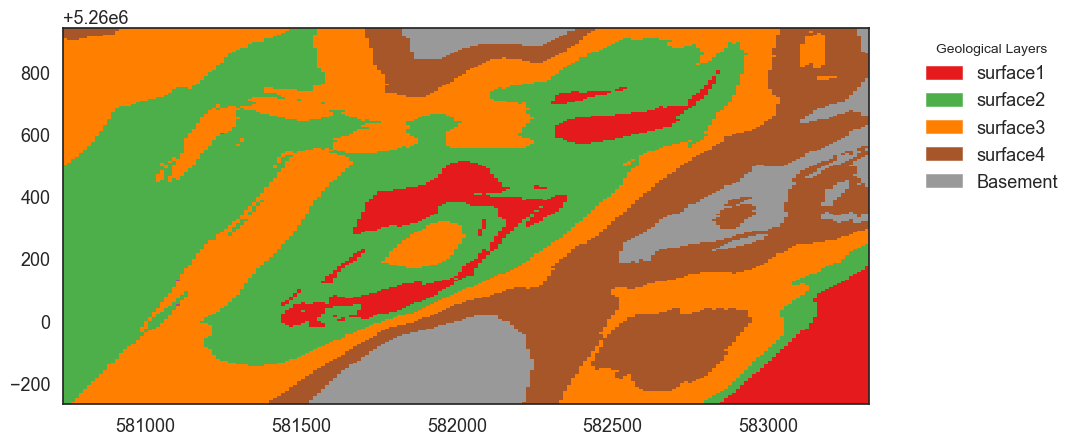

In [36]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np

geo_map = np.flipud(geo_sol.reshape(XX.shape))

# Display the map
plt.imshow(
    geo_map,
    extent=[xmin, xmax, ymin, ymax],
    cmap="Set1",
    interpolation='none'
)

# Define surface names (youngest → oldest)
layer_names = ["surface1", "surface2", "surface3", "surface4", "Basement"]


# Map colors from the colormap
colors = plt.cm.Set1(np.linspace(0, 1, len(layer_names)))

# Create legend
patches = [mpatches.Patch(color=colors[i], label=layer_names[i]) for i in range(len(layer_names))]
plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left', title="Geological Layers")

plt.show()


Ideally, however, we will want to display the map in GIS software, so we have to generate a georeferenced tif file. 

In [37]:
# Create transform matrix to write tif
transform = rasterio.transform.from_bounds(xmin, ymin, xmax, ymax, XX.shape[0], XX.shape[1])

# write tif
with rasterio.open(
        "geomap_Hochgrat_15_09_25.tif",
        mode="w",
        driver="GTiff",
        height=geo_map.shape[0],
        width=geo_map.shape[1],
        count=1,
        dtype=geo_map.dtype,
        crs=dtm.crs,
        transform=transform,
) as new_dataset:
        new_dataset.write(geo_map, 1)

In [38]:
m.add_raster("geomap_Hochgrat.tif", layer_name="geo map")

In [39]:
m

Map(bottom=733736.0, center=[47.4907615, 10.09], controls=(ZoomControl(options=['position', 'zoom_in_text', 'z…

## Generate the custom cross section

In [40]:
#Now creating a custom cross section with defined start and end points

gp.set_section_grid(
    grid=geo_model.grid,
    section_dict={
        'section': ([582250, 5259750], [581250, 5261000], [200,150])
    }
)

Active grids: GridTypes.CUSTOM|SECTIONS|NONE


,start,stop,resolution,dist
section,"[582250, 5259750]","[581250, 5261000]","[200, 150]",1600.781059


In [41]:
# Display a basic cross section of input data
#gpv.plot_2d(geo_model)

<function gempy_viewer.modules.plot_2d.drawer_traces_2d.plot_section_traces(gempy_model: gempy.core.data.geo_model.GeoModel, ax, section_names: list[str] = None)>

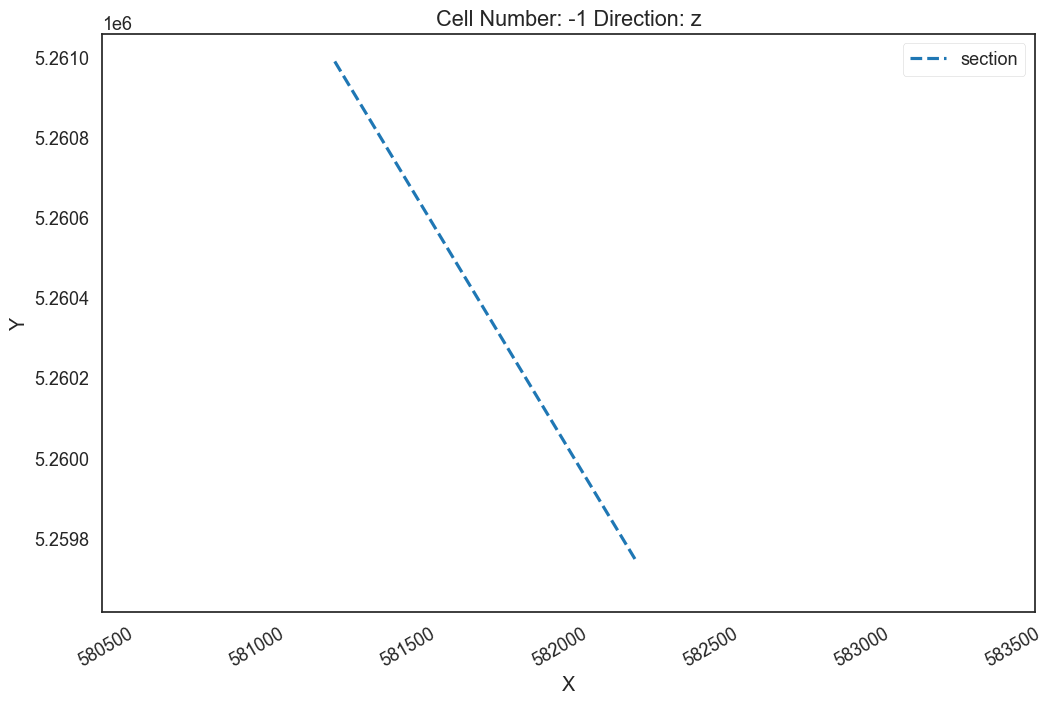

In [42]:
# Show custom cross-section traces
gpv.plot_section_traces(geo_model)




In [43]:
# Recompute model as a new grid was added
gp.compute_model(geo_model)

Setting Backend To: AvailableBackends.numpy
Chunking done: 37 chunks


Solutions(3 Octree Levels, 4 DualContouringMeshes)

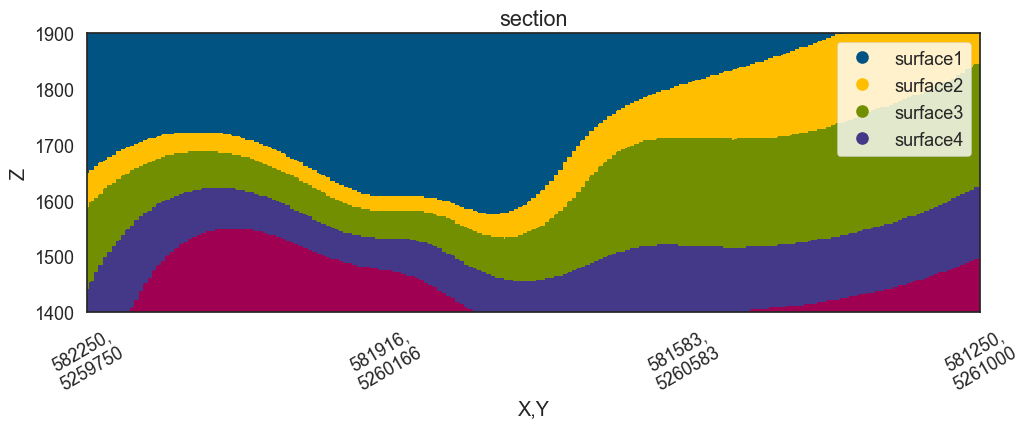

In [44]:
# Display custom cross-sections
gpv.plot_2d(geo_model, section_names=['section'], show_data=False)

## Plotting stereonet with mplstereonet


In [45]:
ori_df

,X,Y,Z,dip,azimuth,formation,polarity
0,583654.299015,5.260278e+06,1287.043091,53,161,formation01,1
1,583047.070111,5.260300e+06,1342.298096,43,145,formation02,1
2,583046.194205,5.260362e+06,1350.264038,55,154,formation03,1
3,582960.750288,5.260484e+06,1374.388062,48,329,formation04,1
4,582837.161000,5.260546e+06,1385.579102,33,323,formation05,1
5,582349.638290,5.260784e+06,1517.892090,30,151,formation06,1
6,582307.794815,5.260784e+06,1515.967041,63,150,formation07,1
7,581932.496132,5.260686e+06,1570.537109,53,159,formation08,1
8,582018.347958,5.260533e+06,1585.563110,54,166,formation09,1
9,581916.757696,5.260315e+06,1568.286133,54,332,formation10,1


In [46]:
import sys, mplstereonet

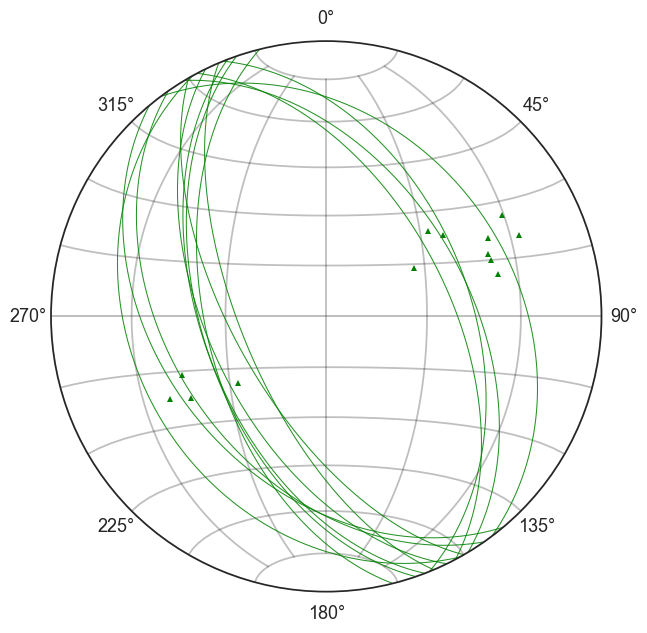

In [47]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='stereonet')
ax.pole(ori_df["azimuth"], ori_df["dip"], 'g^', markersize=4)
ax.plane(ori_df["azimuth"], ori_df["dip"], 'g-', linewidth=0.75, alpha=0.85)
ax.grid(True, color="black", alpha=0.25)
plt.show()

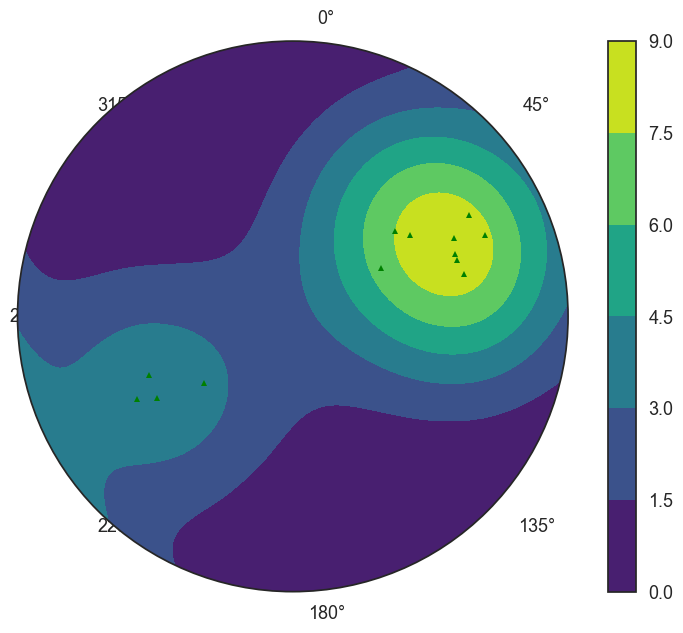

In [48]:
fig, ax = mplstereonet.subplots()
cax = ax.density_contourf(ori_df["azimuth"], ori_df["dip"], measurement='poles', cmap='viridis', alpha=1)
fig.colorbar(cax)
ax.pole(ori_df["azimuth"], ori_df["dip"], 'g^', markersize=4)
ax.grid(True, color="black", alpha=0.25)
plt.show()

## calculate the opening angle of the fold limbs

In [ ]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
import math


# Convert dip & azimuth to unit normal vectors

ori_df['dip_rad'] = np.deg2rad(ori_df['dip'])
ori_df['az_rad'] = np.deg2rad(ori_df['azimuth'])

ori_df['nx'] = -np.sin(ori_df['dip_rad']) * np.sin(ori_df['az_rad'])
ori_df['ny'] = -np.sin(ori_df['dip_rad']) * np.cos(ori_df['az_rad'])
ori_df['nz'] = np.cos(ori_df['dip_rad'])

# Normalize
norms = np.sqrt(ori_df['nx']**2 + ori_df['ny']**2 + ori_df['nz']**2)
ori_df['nxu'] = ori_df['nx'] / norms
ori_df['nyu'] = ori_df['ny'] / norms
ori_df['nzu'] = ori_df['nz'] / norms

# Cluster normals into 2 limb groups
X = ori_df[['nxu','nyu','nzu']].values
kmeans = KMeans(n_clusters=2, random_state=0).fit(X)
ori_df['cluster'] = kmeans.labels_

# Compute mean normal per limb
means = []
for c in sorted(ori_df['cluster'].unique()):
    n_mean = ori_df.loc[ori_df['cluster']==c, ['nxu','nyu','nzu']].mean().values
    n_mean /= np.linalg.norm(n_mean)
    means.append(n_mean)
    print(f"Limb {c} mean normal: {n_mean}")

# Compute opening (interlimb) angle
dot_product = np.dot(means[0], means[1])
dot_product = np.clip(dot_product, -1, 1)
angle_rad = np.arccos(abs(dot_product))   # acute angle between planes
angle_deg = np.degrees(angle_rad)

print(f"\n📐 Interlimb (opening) angle = {angle_deg:.2f}°")

# show the limb each point belongs to

print("\nCluster assignment per formation:")
print(ori_df[['formation', 'dip', 'azimuth', 'cluster']])


Limb 0 mean normal: [-0.33477831  0.6947035   0.63664003]
Limb 1 mean normal: [ 0.34487349 -0.62295787  0.70212945]

📐 Interlimb (opening) angle = 84.19°

Cluster assignment per formation:
      formation  dip  azimuth  cluster
0   formation01   53      161        0
1   formation02   43      145        0
2   formation03   55      154        0
3   formation04   48      329        1
4   formation05   33      323        1
5   formation06   30      151        0
6   formation07   63      150        0
7   formation08   53      159        0
8   formation09   54      166        0
9   formation10   54      332        1
10  formation11   47      338        1
11  formation12   65      157        0
12  formation13   40      140        0


# *Special Note*

 The group of students who participated in the Allgäu field trip in 2025 contributed to the collection of field observations used in this work. During the modeling stage, @Tianyi Chen contributed to parts of the QGIS processing and collaborated in several modeling decisions. @Nils Chudala provided an initial version of the geomodel notebook and continuously supervised the modeling workflow throughout the project.

Many thanks to everyone for their valuable contributions.